**TASK 3 – COLLEGE EVENT FEEDBACK ANALYSIS**

Future Interns – Data Science & Analytics Internship

**STEP 1: Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from wordcloud import WordCloud

sns.set(style="whitegrid")

**STEP 2: Load Dataset**

In [ ]:
# Load dataset
file_path = ("student_feedback.csv")
df = pd.read_csv(file_path)

# Display first rows
df.head()


,Unnamed: 0,Student ID,Well versed with the subject,Explains concepts in an understandable way,Use of presentations,Degree of difficulty of assignments,Solves doubts willingly,Structuring of the course,Provides support for students going above and beyond,Course recommendation based on relevance
0,0,340,5,2,7,6,9,2,1,8
1,1,253,6,5,8,6,2,1,2,9
2,2,680,7,7,6,5,4,2,3,1
3,3,806,9,6,7,1,5,9,4,6
4,4,632,8,10,8,4,6,6,9,9


**STEP 3: Data Cleaning**

In [ ]:
# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Check missing values
df.isnull().sum()

,0
Unnamed: 0,0
Student ID,0
Well versed with the subject,0
Explains concepts in an understandable way,0
Use of presentations,0
Degree of difficulty of assignments,0
Solves doubts willingly,0
Structuring of the course,0
Provides support for students going above and beyond,0
Course recommendation based on relevance,0


In [ ]:
# Fill missing numeric values with column mean
numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

**STEP 4: Rating Analysis (Satisfaction Trends)**

In [ ]:
rating_columns = [
    'Well versed with the subject',
    'Explains concepts in an understandable way',
    'Use of presentations',
    'Degree of difficulty of assignments',
    'Solves doubts willingly',
    'Structuring of the course',
    'Provides support for students going above and beyond',
    'Course recommendation based on relevance'
]

# Average ratings
avg_ratings = df[rating_columns].mean().sort_values(ascending=False)

avg_ratings

,0
Well versed with the subject,7.497502
Explains concepts in an understandable way,6.081918
Use of presentations,5.942058
Provides support for students going above and beyond,5.662338
Structuring of the course,5.636364
Course recommendation based on relevance,5.598402
Solves doubts willingly,5.474525
Degree of difficulty of assignments,5.430569


Visualization – Average Ratings

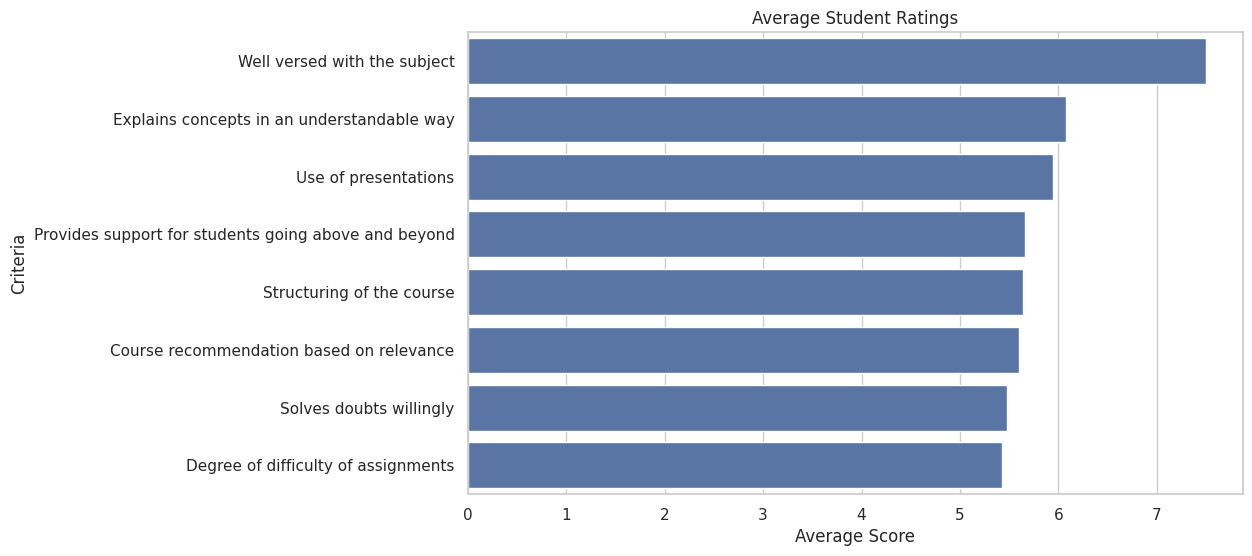

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(x=avg_ratings.values, y=avg_ratings.index)
plt.title("Average Student Ratings")
plt.xlabel("Average Score")
plt.ylabel("Criteria")
plt.show()

**STEP 5: Sentiment Analysis (Text Feedback)**

In [ ]:
# Detect text feedback column automatically
text_col = None
for col in df.columns:
    if df[col].dtype == "object":
        text_col = col
        break

text_col

If Text Feedback Exists → Perform Sentiment Analysis

In [ ]:
if text_col:
    analyzer = SentimentIntensityAnalyzer()

    df['Sentiment Score'] = df[text_col].astype(str).apply(
        lambda x: analyzer.polarity_scores(x)['compound']
    )

    df['Sentiment'] = df['Sentiment Score'].apply(
        lambda x: 'Positive' if x > 0.05 else 'Negative' if x < -0.05 else 'Neutral'
    )

    df[['Sentiment', 'Sentiment Score']].head()
else:
    print("⚠ No text feedback column found – sentiment analysis skipped.")

⚠ No text feedback column found – sentiment analysis skipped.


**STEP 6: Correlation Analysis**

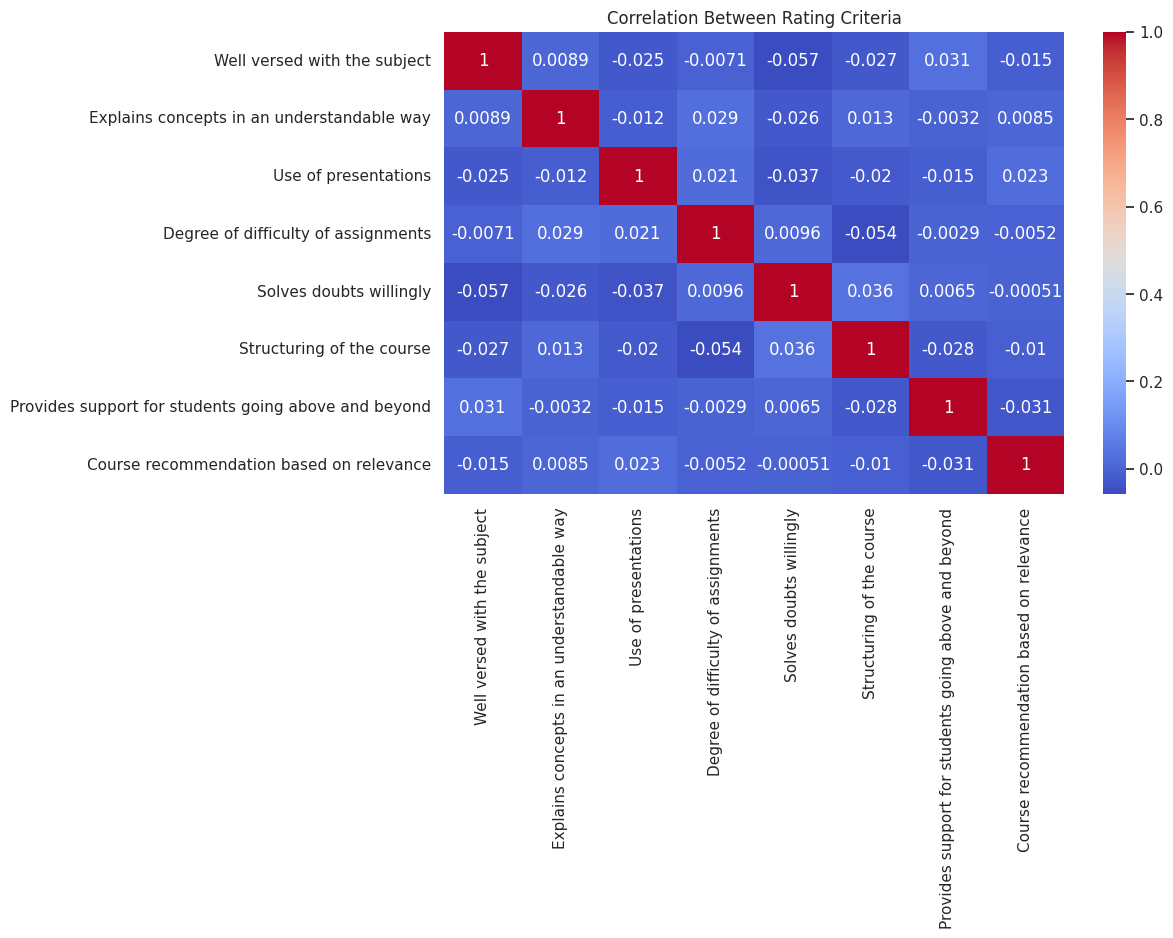

In [12]:
plt.figure(figsize=(10,6))
sns.heatmap(df[rating_columns].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Between Rating Criteria")
plt.show()

**STEP 7: Key Insights**

In [16]:
print("- Highest Rated Aspect:", avg_ratings.index[0])
print("- Lowest Rated Aspect:", avg_ratings.index[-1])

- Highest Rated Aspect: Well versed with the subject
- Lowest Rated Aspect: Degree of difficulty of assignments


**STEP 8: Final Recommendations**

* Improve lower-rated aspects such as course structure and difficulty alignment.
* Encourage more interactive sessions for better engagement.
* Provide additional learning resources for advanced students.
* Address recurring issues highlighted in negative feedback comments.